# Random Forest Model: Predicting Energy Etiquette


## 1. Load and Explore Data

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('.data/final_cleaned.csv')

print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (166680, 72)

Data Types:
Année                                                    int64
Adresse                                                 object
Code Commune                                             int64
Nom Commune                                             object
Segment de client                                       object
                                                        ...   
type_generateur_froid                                   object
systeme_production_electricite_origine_renouvelable     object
surface_habitable                                      float64
value_etiquette                                        float64
etiquette_calculee                                      object
Length: 72, dtype: object


## 2. Feature Selection: Columns to Remove

In [2]:
cols_to_remove = [
    # Identifiers & Keys
    'ban_id', 'identifiant_ban', 'Année', 'numero_dpe',
    
    # Address/Location (already used for joining, no predictive value)
    'Adresse', 'Nom Commune', 'Code Commune', 'adresse_full', 'adresse_ban',
    
    # BAN matching scores (not about building characteristics)
    'ban_add', 'ban_score', 'score_ban',
    
    # Target variables (we're predicting these)
    'etiquette_calculee', 'value_etiquette',
    
    # Consumption columns (target leaked info - we calculate value_etiquette FROM these)
    'Consommation annuelle totale de l\'adresse (MWh)',
    'consommation_annuelle_moyenne_par_site_de_ladresse_mwh',
    'Segment de client', 'Nombre de logements', 'nombre_appartement',
    'position_logement_dans_immeuble',
    
    # DPE reference etiquette (not useful - we're building our own)
    'etiquette_dpe', 'etiquette_gaz', 'etiquette_ges',
    
    # Codes/Regional info
    'Code Région', 'Code EPCI',
]
cols_to_remove = [col for col in cols_to_remove if col in df.columns]

print("Columns to REMOVE:")
for col in sorted(cols_to_remove):
    print(f"  - {col}")

X = df.drop(columns=cols_to_remove)

# Target variables
y_etiquette = df['etiquette_calculee']
y_value = df['value_etiquette']

print(f"\nRemaining features: {X.shape[1]}")
print(f"\nFeature columns:")
for col in X.columns:
    print(f"  - {col} ({X[col].dtype})")

Columns to REMOVE:
  - Adresse
  - Année
  - Code Commune
  - Code Région
  - Consommation annuelle totale de l'adresse (MWh)
  - Nom Commune
  - Nombre de logements
  - Segment de client
  - adresse_ban
  - adresse_full
  - ban_add
  - ban_id
  - ban_score
  - consommation_annuelle_moyenne_par_site_de_ladresse_mwh
  - etiquette_calculee
  - etiquette_dpe
  - etiquette_ges
  - identifiant_ban
  - nombre_appartement
  - numero_dpe
  - position_logement_dans_immeuble
  - score_ban
  - value_etiquette

Remaining features: 49

Feature columns:
  - Code Département (int64)
  - type_batiment (object)
  - periode_construction (object)
  - type_installation_chauffage (object)
  - type_installation_ecs (object)
  - nombre_niveau_immeuble (float64)
  - typologie_logement (object)
  - appartement_non_visite (float64)
  - classe_inertie_batiment (object)
  - indicateur_confort_ete (object)
  - protection_solaire_exterieure (float64)
  - logement_traversant (float64)
  - presence_brasseur_air (floa

## 3. Data Preprocessing & Train/Test Split

In [3]:
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()
label_encoders = {}

# Encode categorical columns to numeric codes
categorical_cols = X_encoded.select_dtypes(include=['object']).columns
print(f"Categorical columns to encode: {list(categorical_cols)}\n")

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le

# Split data for etiquette_calculee (classification)
X_train_et, X_test_et, y_train_et, y_test_et = train_test_split(
    X_encoded, y_etiquette, test_size=0.2, random_state=42, stratify=y_etiquette
)

# Split data for value_etiquette (regression)
X_train_val, X_test_val, y_train_val, y_test_val = train_test_split(
    X_encoded, y_value, test_size=0.2, random_state=42
)

print(f"\nEtiquette (Classification):")
print(f"  Train: {X_train_et.shape}, Test: {X_test_et.shape}")

print(f"\nValue_Etiquette (Regression):")
print(f"  Train: {X_train_val.shape}, Test: {X_test_val.shape}")

Categorical columns to encode: ['type_batiment', 'periode_construction', 'type_installation_chauffage', 'type_installation_ecs', 'typologie_logement', 'classe_inertie_batiment', 'indicateur_confort_ete', 'qualite_isolation_enveloppe', 'qualite_isolation_murs', 'qualite_isolation_plancher_haut_comble_amenage', 'qualite_isolation_plancher_haut_comble_perdu', 'qualite_isolation_plancher_haut_toit_terrasse', 'qualite_isolation_plancher bas', 'qualite_isolation_menuiseries', 'type_energie_n1', 'type_energie_n2', 'type_energie_n3', 'type_energie_principale_chauffage', 'type_generateur_chauffage_principal', 'type_energie_principale_ecs', 'type_ventilation', 'type_generateur_froid', 'systeme_production_electricite_origine_renouvelable']


Etiquette (Classification):
  Train: (133344, 49), Test: (33336, 49)

Value_Etiquette (Regression):
  Train: (133344, 49), Test: (33336, 49)


## 4. Random Forest Model for Etiquette (Classification)

In [4]:
print("Training Random Forest Classifier for etiquette_calculee...")
rf_etiquette = RandomForestClassifier(
    n_estimators=15,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_etiquette.fit(X_train_et, y_train_et)
print("Training complete")

# Predictions
y_pred_et = rf_etiquette.predict(X_test_et)

# Metrics
accuracy = accuracy_score(y_test_et, y_pred_et)
precision = precision_score(y_test_et, y_pred_et, average='weighted', zero_division=0)
recall = recall_score(y_test_et, y_pred_et, average='weighted', zero_division=0)
f1 = f1_score(y_test_et, y_pred_et, average='weighted', zero_division=0)

print(f"\nEtiquette Model Performance:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

Training Random Forest Classifier for etiquette_calculee...
Training complete

Etiquette Model Performance:
  Accuracy:  0.9023
  Precision: 0.9002
  Recall:    0.9023
  F1-Score:  0.9000


## 5. Random Forest Model for Value_Etiquette (Regression)

In [5]:
print("Training Random Forest Regressor for value_etiquette...")
rf_value = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_value.fit(X_train_val, y_train_val)
print("Training complete")

# Predictions
y_pred_val = rf_value.predict(X_test_val)

# Metrics
mae = mean_absolute_error(y_test_val, y_pred_val)
rmse = np.sqrt(mean_squared_error(y_test_val, y_pred_val))
r2 = r2_score(y_test_val, y_pred_val)

print(f"\nValue_Etiquette Model Performance:")
print(f"  MAE (Mean Absolute Error):  {mae:.4f}")
print(f"  RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"  R² Score: {r2:.4f}")

Training Random Forest Regressor for value_etiquette...
Training complete

Value_Etiquette Model Performance:
  MAE (Mean Absolute Error):  15.2718
  RMSE (Root Mean Squared Error): 174.5860
  R² Score: 0.9294


## 6. Feature Importance Analysis

In [6]:
importance_et = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': rf_etiquette.feature_importances_
}).sort_values('importance', ascending=False)


print("Top 15 Features for Etiquette Prediction:")
print(importance_et.head(15).to_string(index=False))


Top 15 Features for Etiquette Prediction:
                          feature  importance
                    type_batiment    0.097860
      type_energie_principale_ecs    0.095305
                  type_energie_n1    0.081734
type_energie_principale_chauffage    0.080485
                       besoin_ecs    0.080328
            type_installation_ecs    0.057351
                  type_energie_n2    0.052023
      type_installation_chauffage    0.049384
           nombre_niveau_immeuble    0.039435
                surface_habitable    0.035750
  deperditions_renouvellement_air    0.035182
           deperditions_enveloppe    0.028351
    apport_solaire_saison_chauffe    0.023934
             periode_construction    0.018635
                 besoin_chauffage    0.018575


In [7]:
importance_val = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': rf_value.feature_importances_
}).sort_values('importance', ascending=False)
print("Top 15 Features for Value_Etiquette Prediction:")
print(importance_val.head(15).to_string(index=False))

Top 15 Features for Value_Etiquette Prediction:
                          feature  importance
                  ubat_w_par_m2_k    0.170351
             periode_construction    0.156761
                surface_habitable    0.111128
          classe_inertie_batiment    0.065239
    qualite_isolation_menuiseries    0.062308
                 type_ventilation    0.051869
           nombre_niveau_immeuble    0.046620
    deperditions_ponts_thermiques    0.046396
   qualite_isolation_plancher bas    0.044058
                 Code Département    0.036343
type_energie_principale_chauffage    0.027077
                       besoin_ecs    0.022717
  deperditions_renouvellement_air    0.022489
                  type_energie_n1    0.013727
                  type_energie_n2    0.012846


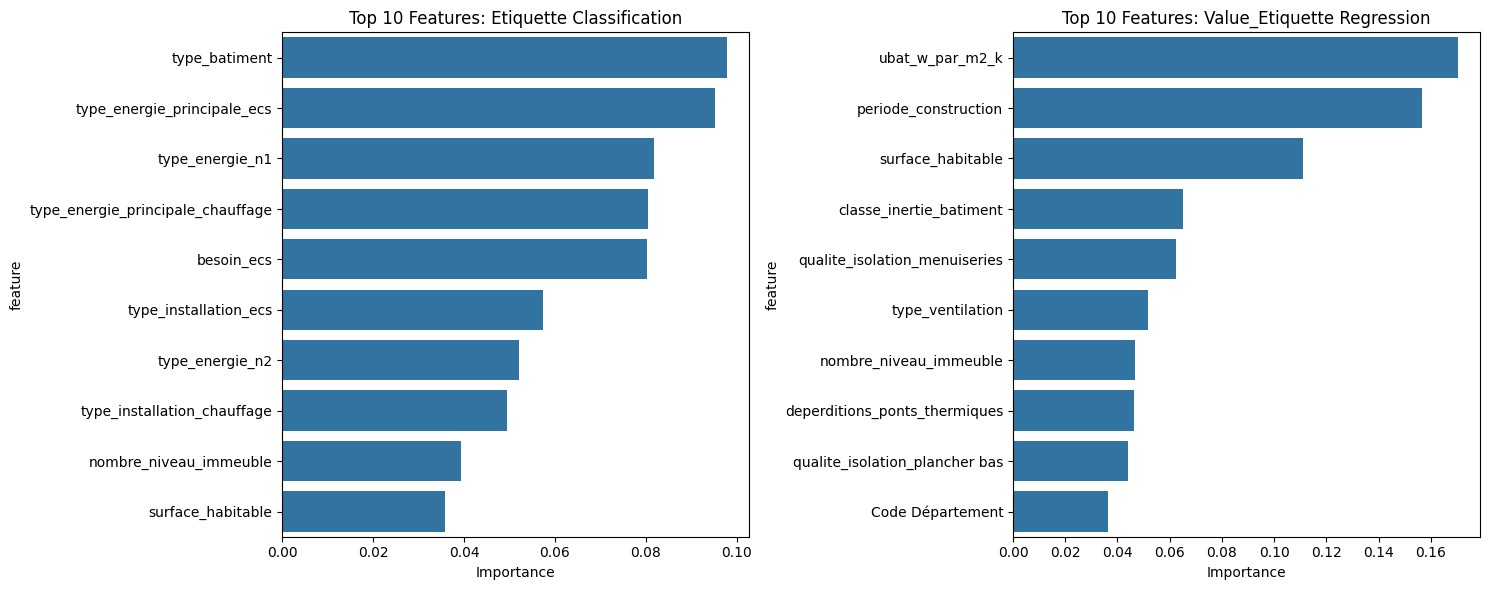

In [8]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Etiquette importance
sns.barplot(data=importance_et.head(10), x='importance', y='feature', ax=axes[0])
axes[0].set_title('Top 10 Features: Etiquette Classification')
axes[0].set_xlabel('Importance')

# Value importance
sns.barplot(data=importance_val.head(10), x='importance', y='feature', ax=axes[1])
axes[1].set_title('Top 10 Features: Value_Etiquette Regression')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

## Save Models for Production

In [9]:
import joblib
from pathlib import Path

# Create model directory
model_dir = Path('./.model')
model_dir.mkdir(exist_ok=True)

# Save both models
print("Saving models to .model/")
print("=" * 60)

# 1. Save etiquette model (classifier)
model_et_path = model_dir / 'rf_etiquette.joblib'
joblib.dump(rf_etiquette, model_et_path)
print(f"  Saved: {model_et_path}")
print(f"  Size: {model_et_path.stat().st_size / 1024:.1f} KB")

# 2. Save value model (regressor)
model_val_path = model_dir / 'rf_value.joblib'
joblib.dump(rf_value, model_val_path)
print(f"  Saved: {model_val_path}")
print(f"  Size: {model_val_path.stat().st_size / 1024:.1f} KB")

# 3. Save label encoders (for encoding new inputs)
# Note: label_encoders was already created during preprocessing above
encoders_path = model_dir / 'label_encoders.joblib'
joblib.dump(label_encoders, encoders_path)
print(f"  Saved: {encoders_path}")
print(f"  Size: {encoders_path.stat().st_size / 1024:.1f} KB")
print(f"  Categorical columns: {len(label_encoders)}")

# 4. Save feature columns list (for consistent ordering)
features_path = model_dir / 'feature_columns.joblib'
feature_columns = X_encoded.columns.tolist()
joblib.dump(feature_columns, features_path)
print(f"  Saved: {features_path}")

print("\n" + "=" * 60)
print("All models and metadata saved successfully!")
print(f"Total files in .model/: {len(list(model_dir.glob('*.joblib')))}")

Saving models to .model/
  Saved: .model/rf_etiquette.joblib
  Size: 8452.1 KB
  Saved: .model/rf_value.joblib
  Size: 26692.3 KB
  Saved: .model/label_encoders.joblib
  Size: 12.4 KB
  Categorical columns: 23
  Saved: .model/feature_columns.joblib

All models and metadata saved successfully!
Total files in .model/: 4
